In [ ]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region
import dask.dataframe as dd
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

In [4]:
data_test='cisbp'
inputfolder = '/data2st2/junyi/output/atac1112/tobiasbam/'

In [5]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)
df_important_TF.columns=['TF']
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_3174066/4282565885.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [6]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [7]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


/tmp/ipykernel_3174066/747042444.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
/tmp/ipykernel_3174066/747042444.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"


In [8]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [9]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [10]:
TOBIAS_Rsults = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_results.xlsx')

In [11]:
TOBIAS_distances = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_distances.txt')

In [ ]:
df_distance = pd.read_csv(TOBIAS_distances[0],sep='\t')
df_distance.index = df_distance.columns

In [85]:
def calculate_medoids(D, labels):
    """
    Calculate the medoid for each cluster based on a precomputed distance matrix.

    Parameters:
    D (numpy.ndarray): A square symmetric matrix of pairwise distances.
    labels (numpy.ndarray): An array of cluster labels for each point.

    Returns:
    dict: A dictionary where keys are cluster labels and values are the indices of the medoids.
    """
    unique_labels = np.unique(labels)
    medoids = {}
    
    for k in unique_labels:
        # 1. Get indices of points in the current cluster
        cluster_indices = np.where(labels == k)[0]
        
        # 2. Extract the sub-distance matrix for the current cluster
        cluster_distance_matrix = D[np.ix_(cluster_indices, cluster_indices)]
        
        # 3. Calculate the sum of distances for each point in the cluster
        sum_of_distances = np.sum(cluster_distance_matrix, axis=1)
        
        # 4. Find the index of the point with the minimum sum of distances *within the cluster*
        medoid_index_in_cluster = np.argmin(sum_of_distances)
        
        # 5. Map this index back to the original global index
        global_medoid_index = cluster_indices[medoid_index_in_cluster]
        
        medoids[k] = global_medoid_index
        
    return medoids

def get_motif_medoids(df_distance,method='average',threshold=0.5):
    linkage_mat = linkage(squareform(df_distance), method)
    labels = fcluster(linkage_mat, threshold, criterion="distance")		#ordering of the dendrogram
    dict_motif_clusters = dict(zip(df_distance.columns,labels))
    dict_cluster_mot = calculate_medoids(df_distance.values,labels)
    dict_cluster_name = {}
    for key in dict_cluster_mot.keys():
        dict_cluster_name[key] = df_distance.columns[dict_cluster_mot[key]]
    dit_motif_to_medoid = {}
    for key in dict_motif_clusters.keys():
        dit_motif_to_medoid[key] = dict_cluster_name[dict_motif_clusters[key]]
    return dit_motif_to_medoid


# Merge all TOBIAS results on TF level

In [ ]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()

    distance_file = file.replace('bindetect_results.xlsx','bindetect_distances.txt')
    df_distance = pd.read_csv(distance_file,sep='\t')
    df_distance.index = df_distance.columns
    motif2medoids = get_motif_medoids(df_distance)

    df_tobias['motifmedoid'] = df_tobias['output_prefix'].map(motif2medoids).values
    #df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    full_results = pd.concat([full_results, df_tobias], axis=0)
    #results = pd.concat([results, df_expanded_mean], axis=0)



In [95]:
full_results_sub=full_results[full_results.output_prefix==full_results.motifmedoid]

In [97]:
full_results_back = full_results.copy()

In [98]:
full_results = full_results_sub

In [137]:
full_results_sub

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,log2FC,Sex,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2
2,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,10037,0.42342,2329,0.41329,2105,0.06037,...,0.06037,M,Rorb,GABA,HPF_HPF_Sst_GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
3,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,10956,0.36931,2040,0.35638,1798,0.06335,...,0.06335,M,Esr2,GABA,HPF_HPF_Sst_GABA,1.852130e-80,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
8,metacluster_136.3cisbp__M00186_None,metacluster_136.3#cisbp__M00186,None,C_metacluster_136.3#cisbp__M00186,16071,0.57759,5757,0.58494,5772,0.01658,...,0.01658,M,Rfx4,GABA,HPF_HPF_Sst_GABA,1.457450e-43,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
10,metacluster_136.3cisbp__M05888_None,metacluster_136.3#cisbp__M05888,None,C_metacluster_136.3#cisbp__M05888,15498,0.55971,5338,0.56860,5427,0.00440,...,0.00440,M,Rfx2,GABA,HPF_HPF_Sst_GABA,1.863820e-03,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
16,metacluster_16.2cisbp__M00197_None,metacluster_16.2#cisbp__M00197,None,C_metacluster_4.2#cisbp__M00210,15356,0.33109,2573,0.33180,2614,0.01761,...,0.01761,M,Sox8,GABA,HPF_HPF_Sst_GABA,5.274930e-41,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,metacluster_18.3cisbp__M00141_None,metacluster_18.3#cisbp__M00141,None,C_metacluster_18.3#cisbp__M00141,15037,0.53287,4792,0.55629,5195,-0.00969,...,-0.00969,M,Hic1,NN,AMY_MOL-2,4.307470e-22,MOL-2,AMY,Down,MOL-2
340,metacluster_112.4cisbp__M00424_None,metacluster_112.4#cisbp__M00424,None,C_metacluster_42.4#cisbp__M02097,7513,0.27553,1077,0.28518,1116,0.01934,...,0.01934,M,Esx1,NN,AMY_MOL-2,2.868600e-24,MOL-2,AMY,Up,MOL-2
343,metacluster_181.1transfac_public__M00450_None,metacluster_181.1#transfac_public__M00450,None,C_metacluster_181.1#transfac_public__M00450,12590,0.52797,3941,0.56583,4319,-0.02594,...,-0.02594,M,Zic3,NN,AMY_MOL-2,4.536660e-49,MOL-2,AMY,Down,MOL-2
345,metacluster_181.1cisbp__M01023_None,metacluster_181.1#cisbp__M01023,None,C_metacluster_181.1#cisbp__M01022,13903,0.56830,4523,0.61087,4979,-0.03418,...,-0.03418,M,Gli1,NN,AMY_MOL-2,8.026800e-60,MOL-2,AMY,Down,MOL-2


In [139]:
logfiles =[
'/home/junyichen/logs/17binplotAGG.sh.2026-01-05-16-05-40.out',
'/home/junyichen/logs/17binplotAGG.sh.2026-01-04-10-35-26.out',
'/home/junyichen/logs/17binplotAGG.sh.2026-01-02-17-38-29.out',
]

In [ ]:
specific_word = '[STATS]	FPD ('
lines = []
remove_chars = "[]();\t:"
for logfile in logfiles:
    with open(logfile, 'r') as infile:
        filtered_lines = list(map(str.strip, filter(lambda line: specific_word in line, infile)))
    lines+=filtered_lines

In [169]:
specific_word = '[STATS]\tFPD ('
lines = []

remove_chars = "[]();\t:"
table = str.maketrans("", "", remove_chars)

for logfile in logfiles:
    with open(logfile, "r") as infile:
        filtered_lines = [
            line.translate(table).replace(",", " ").strip()
            for line in infile
            if specific_word in line
        ]
    lines += filtered_lines


In [185]:
rows = [ln.split() for ln in lines]

df = pd.DataFrame(rows)


In [271]:
df_score=df.iloc[:,4:]

/tmp/ipykernel_3174066/1375740739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Region Subclass Condition'] = df_score['celltype'].str.replace('_corrected',"")


In [273]:
df_score.columns=['celltype','motif','width','bgscore','midscore','tfbsscore']

In [274]:
df_score['Region Subclass Condition'] = df_score['celltype'].str.replace('_corrected',"")
df_score['Condtion']=df_score['Region Subclass Condition'].str.split("_").str[-1]
df_score['Region Subclass'] = df_score['Region Subclass Condition'].str[:-3]
df_score['Region Subclass'] = df_score['Region Subclass'].str.replace("HIP","HPF")
df_score['motif'] = df_score['motif'].str.replace("_all","")

/tmp/ipykernel_3174066/226307273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Region Subclass Condition'] = df_score['celltype'].str.replace('_corrected',"")
/tmp/ipykernel_3174066/226307273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Condtion']=df_score['Region Subclass Condition'].str.split("_").str[-1]
/tmp/ipykernel_3174066/226307273.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [ ]:
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('HPF_HPF',"")
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('AMY_AMY',"")
# df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('PFC_PFC',"")

/tmp/ipykernel_3174066/917532177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('HPF_HPF',"")
/tmp/ipykernel_3174066/917532177.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_score['Region Subclass'] = df_score['Region Subclass'].str.replace('AMY_AMY',"")
/tmp/ipykernel_3174066/917532177.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [275]:
df_merge = pd.merge(df_score,full_results_sub,how='right',left_on=['Region Subclass','motif'],right_on=['Region Subclass','motifmedoid'])

In [276]:
df_merge['bgscore'] = df_merge['bgscore'].astype(float)
df_merge['midscore'] = df_merge['midscore'].astype(float)
df_merge['tfbsscore'] = df_merge['tfbsscore'].astype(float)
df_merge['width'] = df_merge['width'].astype(float)

In [362]:
df_merge

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00501,-0.00866,-0.01367,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
1,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,10.0,0.00525,-0.00857,-0.01382,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,12.0,0.00574,-0.01065,-0.01639,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
3,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,14.0,0.00614,-0.01136,-0.01750,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
4,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,16.0,0.00618,-0.00944,-0.01562,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329987,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,40.0,0.00699,0.01418,0.00719,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329988,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,42.0,0.00722,0.01341,0.00618,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329989,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,44.0,0.00709,0.01336,0.00628,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329990,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,46.0,0.00698,0.01326,0.00629,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2


In [385]:
df_merge_shallow = df_merge[df_merge.width<14]

In [387]:
df_merge_shallow

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00501,-0.00866,-0.01367,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
1,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,10.0,0.00525,-0.00857,-0.01382,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,12.0,0.00574,-0.01065,-0.01639,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
21,HIP_HPF_Sst_GABA_MW_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00557,-0.00586,-0.01143,HIP_HPF_Sst_GABA_MW,MW,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
22,HIP_HPF_Sst_GABA_MW_corrected,metacluster_121.1cisbp__M00820_None,10.0,0.00572,-0.00521,-0.01094,HIP_HPF_Sst_GABA_MW,MW,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329933,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M01023_None,12.0,0.00586,0.02811,0.02225,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M01023_None,...,Down,-0.03418,M,Gli1,NN,8.026800e-60,MOL-2,AMY,Down,MOL-2
329952,AMY_MOL-2_MC_corrected,metacluster_181.1cisbp__M08023_None,10.0,0.00468,0.02643,0.02174,AMY_MOL-2_MC,MC,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329953,AMY_MOL-2_MC_corrected,metacluster_181.1cisbp__M08023_None,12.0,0.00388,0.03003,0.02614,AMY_MOL-2_MC,MC,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329972,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,10.0,0.00836,0.02073,0.01238,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2


In [388]:
df_merge_mean = df_merge_shallow.groupby(['Region Subclass','Condtion','motif']).max().reset_index()

In [389]:
df_merge_mean

,Region Subclass,Condtion,motif,celltype,width,bgscore,midscore,tfbsscore,Region Subclass Condition,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_0.2cisbp__M00396_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00126,0.00692,0.00598,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_0.2cisbp__M00396_None,...,Down,-0.02722,M,Otx1,Glut,3.291070e-43,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
1,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.10cisbp__M00421_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00207,-0.00006,-0.00200,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.10cisbp__M00421_None,...,Up,0.00379,M,Hoxc10,Glut,8.843790e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.9cisbp__M00389_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00341,-0.00524,-0.00849,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.9cisbp__M00389_None,...,Up,0.00390,M,Hoxc13,Glut,6.505940e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_11.2cisbp__M00818_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00167,-0.00819,-0.00934,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_11.2cisbp__M00818_None,...,Down,-0.06790,M,Nr4a2,Glut,6.851560e-94,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M00991_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.04140,-0.05189,-0.09021,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M00991_None,...,Down,-0.03408,M,Creb1,Glut,7.403020e-46,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13045,PFC_Pericyte,MW,metacluster_67.2cisbp__M00153_None,PFC_Pericyte_MW_corrected,12.0,0.00965,-0.00320,-0.01055,PFC_Pericyte_MW,metacluster_67.2cisbp__M00153_None,...,Up,0.01767,M,E2f3,NN,3.674350e-11,Pericyte,PFC,Up,Pericyte
13046,PFC_Pericyte,MW,metacluster_67.2cisbp__M01011_None,PFC_Pericyte_MW_corrected,12.0,0.02137,-0.07777,-0.09913,PFC_Pericyte_MW,metacluster_67.2cisbp__M01011_None,...,Up,0.00519,M,Foxn4,NN,1.352490e-04,Pericyte,PFC,Up,Pericyte
13047,PFC_Pericyte,MW,metacluster_68.2cisbp__M00437_None,PFC_Pericyte_MW_corrected,12.0,-0.00245,0.02640,0.03104,PFC_Pericyte_MW,metacluster_68.2cisbp__M00437_None,...,Up,0.01032,M,Meis2,NN,6.619600e-13,Pericyte,PFC,Up,Pericyte
13048,PFC_Pericyte,MW,metacluster_8.2cisbp__M01307_None,PFC_Pericyte_MW_corrected,12.0,0.00194,0.00136,-0.00034,PFC_Pericyte_MW,metacluster_8.2cisbp__M01307_None,...,Down,-0.01557,M,Runx2,NN,6.134220e-11,Pericyte,PFC,Down,Pericyte


In [390]:
df_merge_bsfilterer = df_merge_mean[(df_merge_mean.tfbsscore<0)]

In [391]:
df_merge_bsfilterer

,Region Subclass,Condtion,motif,celltype,width,bgscore,midscore,tfbsscore,Region Subclass Condition,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
1,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.10cisbp__M00421_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00207,-0.00006,-0.00200,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.10cisbp__M00421_None,...,Up,0.00379,M,Hoxc10,Glut,8.843790e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.9cisbp__M00389_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00341,-0.00524,-0.00849,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.9cisbp__M00389_None,...,Up,0.00390,M,Hoxc13,Glut,6.505940e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_11.2cisbp__M00818_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.00167,-0.00819,-0.00934,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_11.2cisbp__M00818_None,...,Down,-0.06790,M,Nr4a2,Glut,6.851560e-94,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M00991_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.04140,-0.05189,-0.09021,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M00991_None,...,Down,-0.03408,M,Creb1,Glut,7.403020e-46,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
5,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M01810_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,12.0,0.02873,-0.05462,-0.08156,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M01810_None,...,Down,-0.02333,M,Jdp2,Glut,1.525560e-36,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13044,PFC_Pericyte,MW,metacluster_5.1cisbp__M08039_None,PFC_Pericyte_MW_corrected,12.0,0.00395,-0.01231,-0.01457,PFC_Pericyte_MW,metacluster_5.1cisbp__M08039_None,...,Down,-0.00107,M,Rela,NN,2.545980e-01,Pericyte,PFC,Down,Pericyte
13045,PFC_Pericyte,MW,metacluster_67.2cisbp__M00153_None,PFC_Pericyte_MW_corrected,12.0,0.00965,-0.00320,-0.01055,PFC_Pericyte_MW,metacluster_67.2cisbp__M00153_None,...,Up,0.01767,M,E2f3,NN,3.674350e-11,Pericyte,PFC,Up,Pericyte
13046,PFC_Pericyte,MW,metacluster_67.2cisbp__M01011_None,PFC_Pericyte_MW_corrected,12.0,0.02137,-0.07777,-0.09913,PFC_Pericyte_MW,metacluster_67.2cisbp__M01011_None,...,Up,0.00519,M,Foxn4,NN,1.352490e-04,Pericyte,PFC,Up,Pericyte
13048,PFC_Pericyte,MW,metacluster_8.2cisbp__M01307_None,PFC_Pericyte_MW_corrected,12.0,0.00194,0.00136,-0.00034,PFC_Pericyte_MW,metacluster_8.2cisbp__M01307_None,...,Down,-0.01557,M,Runx2,NN,6.134220e-11,Pericyte,PFC,Down,Pericyte


# Vizualize the results as heatmap

In [367]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass']
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if ('FDR' not in results.columns) and ('MC_MW_pvalue' in results.columns):
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results


In [ ]:
# full_selected.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
# full_selected
# full_selected.drop_duplicates(subset=['Region Subclass','cluster'])

NameError: name 'full_selected' is not defined

In [368]:
full_results = add_columns(full_results)
#avg_results = add_columns(results)
#full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
# full_results_filtered = full_results[full_results.FDR < 0.05]
# full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
# full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
# full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)
#results=avg_results[avg_results.FDR <0.05]
results=full_results[full_results.FDR < 0.05]
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_3174066/3474490407.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
/tmp/ipykernel_3174066/3474490407.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['log2FC'] = results['MC_MW_change']
/tmp/ipykernel_3174066/3474490407.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [369]:
results.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
results_back = results.copy()

/tmp/ipykernel_3174066/1508574533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)


In [370]:
results.drop_duplicates(subset=['Region Subclass','cluster'],inplace=True)

/tmp/ipykernel_3174066/4274392065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results.drop_duplicates(subset=['Region Subclass','cluster'],inplace=True)


In [371]:
results['name_tf'] = results['TF']+"_"+results['motifmedoid']

/tmp/ipykernel_3174066/2235640212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['name_tf'] = results['TF']+"_"+results['motifmedoid']


In [372]:
df_merge_bsfilterer

,Region Subclass,Condtion,motif,celltype,width,bgscore,midscore,tfbsscore,Region Subclass Condition,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
1,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.10cisbp__M00421_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.00221,-0.00006,-0.00200,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.10cisbp__M00421_None,...,Up,0.00379,M,Hoxc10,Glut,8.843790e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.9cisbp__M00389_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.00343,-0.00417,-0.00760,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.9cisbp__M00389_None,...,Up,0.00390,M,Hoxc13,Glut,6.505940e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_11.2cisbp__M00818_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.00188,-0.00819,-0.00934,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_11.2cisbp__M00818_None,...,Down,-0.06790,M,Nr4a2,Glut,6.851560e-94,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M00991_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.04404,-0.05189,-0.09021,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M00991_None,...,Down,-0.03408,M,Creb1,Glut,7.403020e-46,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
5,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M01810_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.02991,-0.05372,-0.08156,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M01810_None,...,Down,-0.02333,M,Jdp2,Glut,1.525560e-36,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15660,PFC_Pericyte,MW,metacluster_5.1transfac_public__M00194_None,PFC_Pericyte_MW_corrected,14.0,0.00715,-0.01531,-0.02246,PFC_Pericyte_MW,metacluster_5.1transfac_public__M00194_None,...,Down,-0.01777,M,Rela,NN,2.194150e-22,Pericyte,PFC,Down,Pericyte
15661,PFC_Pericyte,MW,metacluster_67.2cisbp__M00153_None,PFC_Pericyte_MW_corrected,14.0,0.01058,-0.00320,-0.01055,PFC_Pericyte_MW,metacluster_67.2cisbp__M00153_None,...,Up,0.01767,M,E2f3,NN,3.674350e-11,Pericyte,PFC,Up,Pericyte
15662,PFC_Pericyte,MW,metacluster_67.2cisbp__M01011_None,PFC_Pericyte_MW_corrected,14.0,0.02137,-0.03408,-0.05154,PFC_Pericyte_MW,metacluster_67.2cisbp__M01011_None,...,Up,0.00519,M,Foxn4,NN,1.352490e-04,Pericyte,PFC,Up,Pericyte
15664,PFC_Pericyte,MW,metacluster_8.2cisbp__M01307_None,PFC_Pericyte_MW_corrected,14.0,0.00247,0.00136,-0.00034,PFC_Pericyte_MW,metacluster_8.2cisbp__M01307_None,...,Down,-0.01557,M,Runx2,NN,6.134220e-11,Pericyte,PFC,Down,Pericyte


In [373]:
df_merge_bsfilterer.loc[:,['Region Subclass','motif']]

,Region Subclass,motif
1,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_1.10cisbp__M00421_None
2,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_1.9cisbp__M00389_None
3,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_11.2cisbp__M00818_None
4,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_111.3cisbp__M00991_None
5,AMY_AMY_Cav1_Frmpd1_Glut,metacluster_111.3cisbp__M01810_None
...,...,...
15660,PFC_Pericyte,metacluster_5.1transfac_public__M00194_None
15661,PFC_Pericyte,metacluster_67.2cisbp__M00153_None
15662,PFC_Pericyte,metacluster_67.2cisbp__M01011_None
15664,PFC_Pericyte,metacluster_8.2cisbp__M01307_None


In [392]:
df_merge_bsfilterer.drop_duplicates(inplace=True)

/tmp/ipykernel_3174066/954353739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge_bsfilterer.drop_duplicates(inplace=True)


In [375]:
df_merge_bsfilterer

,Region Subclass,Condtion,motif,celltype,width,bgscore,midscore,tfbsscore,Region Subclass Condition,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
1,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.10cisbp__M00421_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.00221,-0.00006,-0.00200,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.10cisbp__M00421_None,...,Up,0.00379,M,Hoxc10,Glut,8.843790e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
2,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_1.9cisbp__M00389_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.00343,-0.00417,-0.00760,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_1.9cisbp__M00389_None,...,Up,0.00390,M,Hoxc13,Glut,6.505940e-05,AMY_Cav1_Frmpd1_Glut,AMY,Up,AMY_Cav1_Frmpd1_Glut
3,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_11.2cisbp__M00818_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.00188,-0.00819,-0.00934,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_11.2cisbp__M00818_None,...,Down,-0.06790,M,Nr4a2,Glut,6.851560e-94,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
4,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M00991_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.04404,-0.05189,-0.09021,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M00991_None,...,Down,-0.03408,M,Creb1,Glut,7.403020e-46,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
5,AMY_AMY_Cav1_Frmpd1_Glut,MC,metacluster_111.3cisbp__M01810_None,AMY_AMY_Cav1_Frmpd1_Glut_MC_corrected,14.0,0.02991,-0.05372,-0.08156,AMY_AMY_Cav1_Frmpd1_Glut_MC,metacluster_111.3cisbp__M01810_None,...,Down,-0.02333,M,Jdp2,Glut,1.525560e-36,AMY_Cav1_Frmpd1_Glut,AMY,Down,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15660,PFC_Pericyte,MW,metacluster_5.1transfac_public__M00194_None,PFC_Pericyte_MW_corrected,14.0,0.00715,-0.01531,-0.02246,PFC_Pericyte_MW,metacluster_5.1transfac_public__M00194_None,...,Down,-0.01777,M,Rela,NN,2.194150e-22,Pericyte,PFC,Down,Pericyte
15661,PFC_Pericyte,MW,metacluster_67.2cisbp__M00153_None,PFC_Pericyte_MW_corrected,14.0,0.01058,-0.00320,-0.01055,PFC_Pericyte_MW,metacluster_67.2cisbp__M00153_None,...,Up,0.01767,M,E2f3,NN,3.674350e-11,Pericyte,PFC,Up,Pericyte
15662,PFC_Pericyte,MW,metacluster_67.2cisbp__M01011_None,PFC_Pericyte_MW_corrected,14.0,0.02137,-0.03408,-0.05154,PFC_Pericyte_MW,metacluster_67.2cisbp__M01011_None,...,Up,0.00519,M,Foxn4,NN,1.352490e-04,Pericyte,PFC,Up,Pericyte
15664,PFC_Pericyte,MW,metacluster_8.2cisbp__M01307_None,PFC_Pericyte_MW_corrected,14.0,0.00247,0.00136,-0.00034,PFC_Pericyte_MW,metacluster_8.2cisbp__M01307_None,...,Down,-0.01557,M,Runx2,NN,6.134220e-11,Pericyte,PFC,Down,Pericyte


In [393]:
df_selected = df_merge_bsfilterer.loc[:,['Region Subclass','motif']].drop_duplicates()

In [394]:
df_selected.rename({'motif':'motifmedoid'},axis=1,inplace=True)

In [395]:
results = pd.merge(results,df_selected,how='inner',left_on=['Region Subclass','motifmedoid'],right_on=['Region Subclass','motifmedoid'])

In [396]:
results

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,Glut,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,Glut,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,Glut,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,Glut,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4211,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,GABA,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None
4212,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,NN,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None
4213,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None
4214,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,GABA,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None


In [402]:
df_merge[df_merge.TF=='Esrra']

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
2958,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,8.0,0.00188,-0.00582,-0.00770,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2959,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,10.0,0.00207,-0.00642,-0.00849,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2960,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,12.0,0.00226,-0.00664,-0.00889,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2961,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,14.0,0.00242,-0.00662,-0.00905,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2962,HIP_HPF_Sst_GABA_MC_corrected,metacluster_90.4cisbp__M00183_None,16.0,0.00266,-0.00707,-0.00973,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_90.4cisbp__M00183_None,...,Up,0.06378,M,Esrra,GABA,8.401190e-84,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329315,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,40.0,0.00485,-0.00202,-0.00687,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2
329316,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,42.0,0.00463,-0.00129,-0.00592,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2
329317,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,44.0,0.00441,-0.00064,-0.00505,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2
329318,AMY_MOL-2_MW_corrected,metacluster_90.4cisbp__M00183_None,46.0,0.00428,-0.00020,-0.00448,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_90.4cisbp__M00183_None,...,Down,-0.03906,M,Esrra,NN,1.276840e-66,MOL-2,AMY,Down,MOL-2


In [400]:
df_merge.drop_duplicates(subset=['motif'])

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00501,-0.00866,-0.01367,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
42,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M01297_None,8.0,0.00297,-0.00549,-0.00846,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M01297_None,...,Up,0.06335,M,Esr2,GABA,1.852130e-80,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
84,HIP_HPF_Sst_GABA_MC_corrected,metacluster_136.3cisbp__M00186_None,10.0,0.01278,0.01887,0.00609,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_136.3cisbp__M00186_None,...,Up,0.01658,M,Rfx4,GABA,1.457450e-43,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
124,HIP_HPF_Sst_GABA_MC_corrected,metacluster_136.3cisbp__M05888_None,14.0,0.01234,0.01388,0.00154,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_136.3cisbp__M05888_None,...,Up,0.00440,M,Rfx2,GABA,1.863820e-03,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
160,HIP_HPF_Sst_GABA_MC_corrected,metacluster_16.2cisbp__M00197_None,8.0,0.00191,0.00508,0.00317,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_16.2cisbp__M00197_None,...,Up,0.01761,M,Sox8,GABA,5.274930e-41,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220928,AMY_AMY_Ccdc3_Acvr1c_Glut_MC_corrected,metacluster_0.2cisbp__M00515_None,10.0,0.00656,0.00678,0.00022,AMY_AMY_Ccdc3_Acvr1c_Glut_MC,MC,AMY_AMY_Ccdc3_Acvr1c_Glut,metacluster_0.2cisbp__M00515_None,...,Down,-0.00401,M,Obox1,Glut,2.033040e-10,AMY_Ccdc3_Acvr1c_Glut,AMY,Down,AMY_Ccdc3_Acvr1c_Glut
298458,AMY_AMY_Fign_Ostm1_GABA_MC_corrected,metacluster_149.1cisbp__M01723_None,10.0,0.01148,0.00795,-0.00353,AMY_AMY_Fign_Ostm1_GABA_MC,MC,AMY_AMY_Fign_Ostm1_GABA,metacluster_149.1cisbp__M01723_None,...,Down,-0.12151,M,Tcf3,GABA,3.382200e-148,AMY_Fign_Ostm1_GABA,AMY,Down,AMY_Fign_Ostm1_GABA
302128,AMY_AMY_Rspo2_Gm11639_Glut_MC_corrected,metacluster_191.3cisbp__M01479_None,10.0,0.06611,0.04603,-0.02008,AMY_AMY_Rspo2_Gm11639_Glut_MC,MC,AMY_AMY_Rspo2_Gm11639_Glut,metacluster_191.3cisbp__M01479_None,...,Down,-0.07288,M,Etv1,Glut,1.241530e-100,AMY_Rspo2_Gm11639_Glut,AMY,Down,AMY_Rspo2_Gm11639_Glut
312146,AMY_Astrocyte-3_MC_corrected,metacluster_121.1cisbp__M02400_None,8.0,0.00043,-0.23087,-0.23130,AMY_Astrocyte-3_MC,MC,AMY_Astrocyte-3,metacluster_121.1cisbp__M02400_None,...,Down,-0.03191,M,Rxrg,NN,3.798330e-25,Astrocyte-3,AMY,Down,Astrocyte-3


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


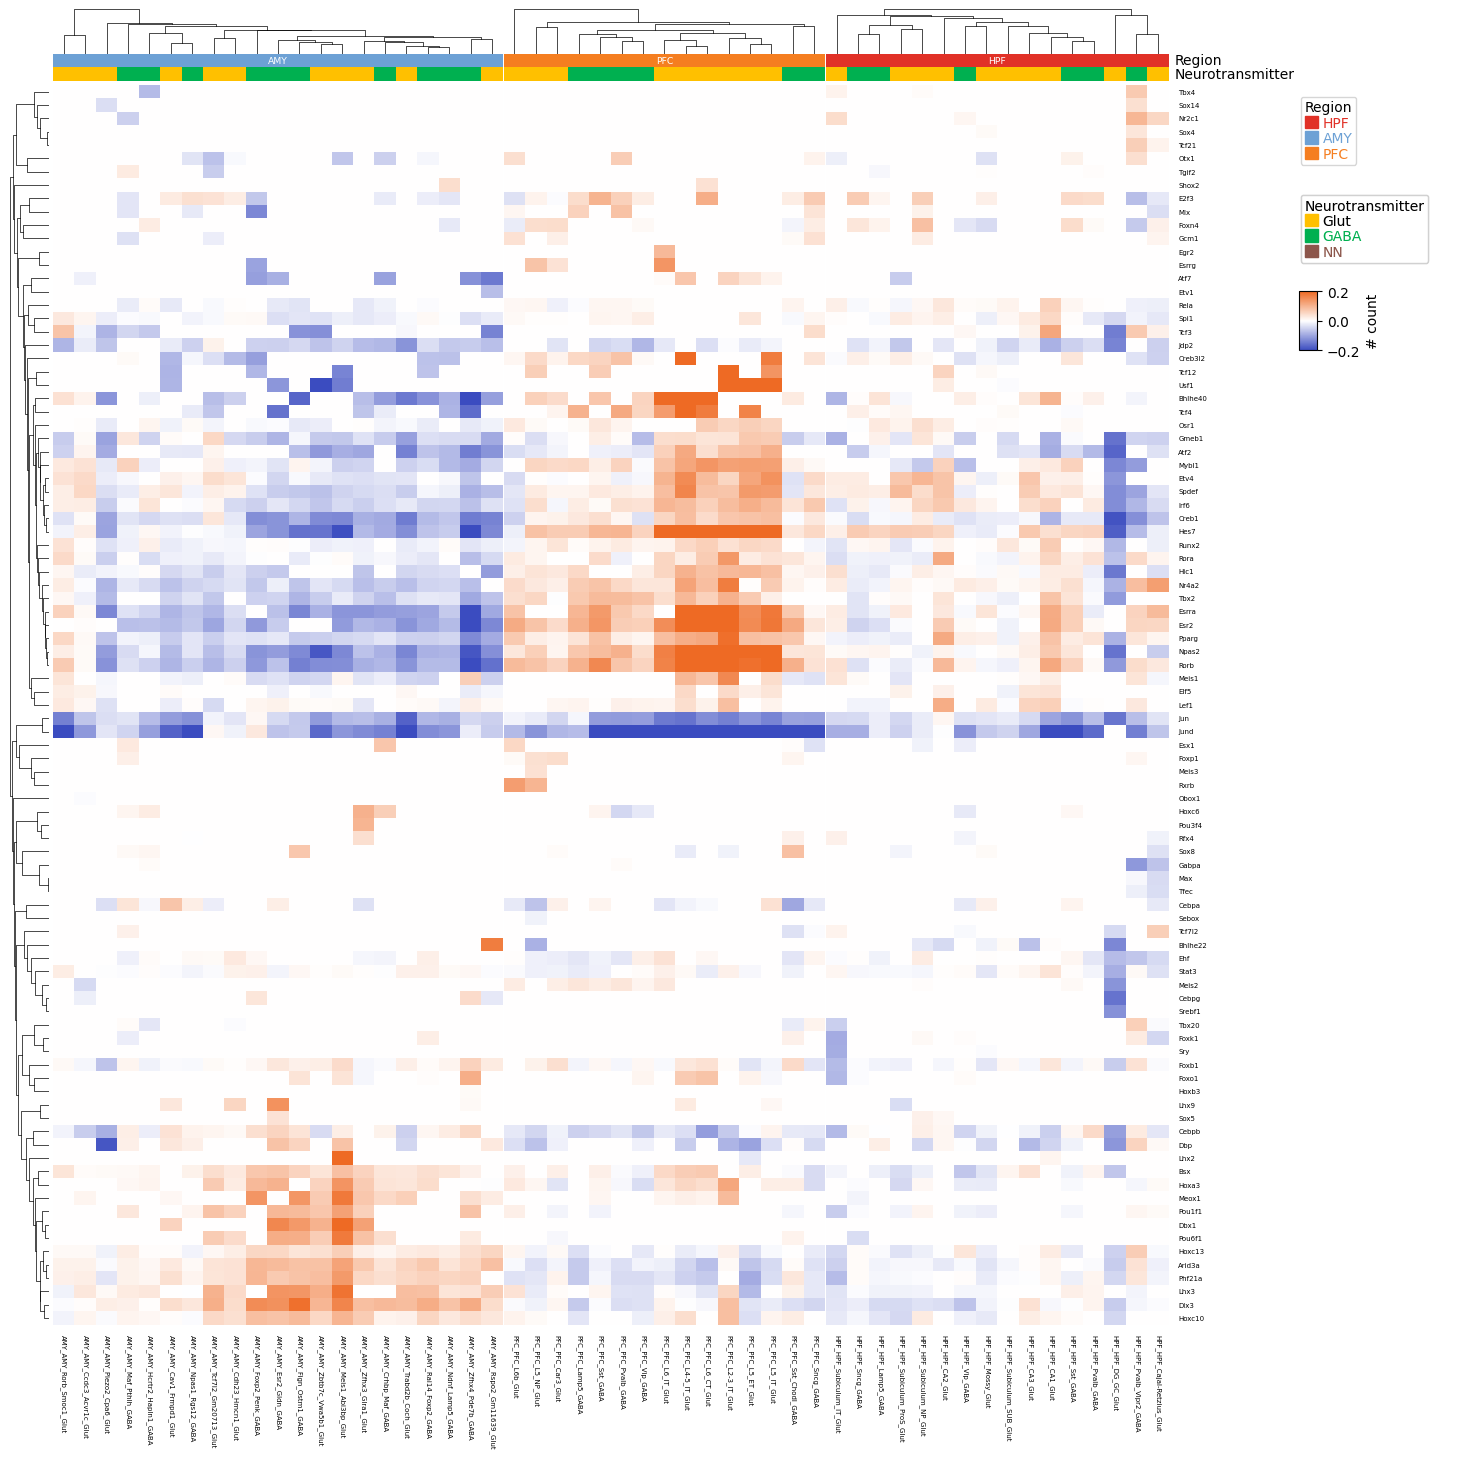

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


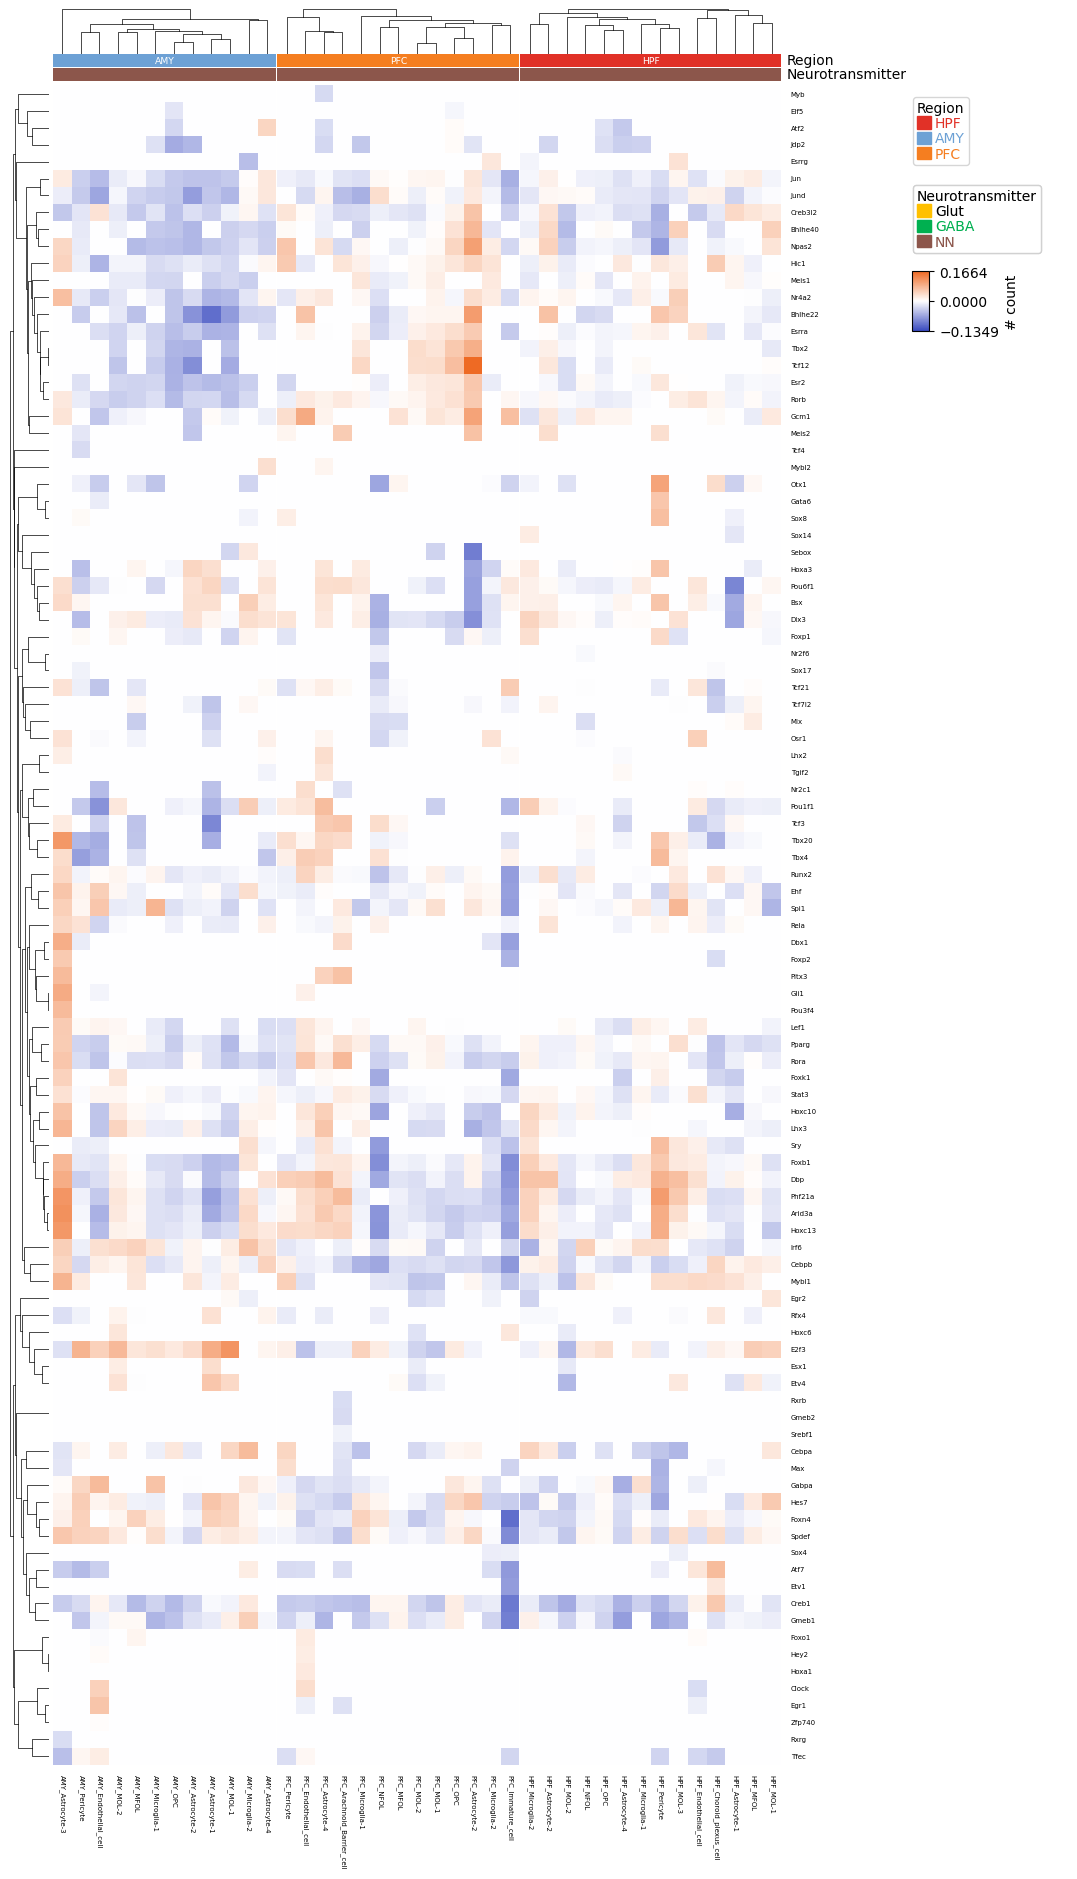

In [398]:

# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_sub_{data_test}.pdf')
cmNN = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_sub_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND)sub_mat_{data_test}.csv')
# matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
# matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')
# denrow = cm.dendrogram_row
# cm.dendrogram_row.dendrogram.keys()
# n = len(cm.dendrogram_row.dendrogram["leaves"])
# k = 10
# labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [404]:
results

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,Glut,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,Glut,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,Glut,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,Glut,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4211,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,GABA,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None
4212,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,NN,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None
4213,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None
4214,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,GABA,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None


In [517]:
results[results.FDR < 0.05]

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,Glut,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,Glut,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,Glut,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,Glut,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4211,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,GABA,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None
4212,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,NN,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None
4213,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None
4214,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,GABA,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None


In [405]:
full_selected = results[results.FDR < 0.05]
full_selected['absLog2FC'] = full_selected['log2FC'].abs()
full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_selected.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

In [406]:
full_selected.sort_values(by=['abs_change','total_tfbs'], ascending=[False,False], inplace=True)
full_selected
full_selected.drop_duplicates(subset=['Region Subclass','cluster'])

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf,absLog2FC
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.41308
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,PFC_PFC_L2-3_IT_Glut,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.36419
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,PFC_PFC_L4-5_IT_Glut,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None,0.34449
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,PFC_PFC_L2-3_IT_Glut,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None,0.33697
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,PFC_PFC_L2-3_IT_Glut,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None,0.33097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4211,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,AMY_AMY_Npas1_Rgs12_GABA,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None,0.00040
4212,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,AMY_OPC,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None,0.00014
4213,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None,0.00012
4214,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,HPF_HPF_Sncg_GABA,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None,0.00007


In [407]:
full_selected['meta_cluster'] = full_selected['Region Subclass'].str.split('_').str[0]

In [518]:
full_selected.to_csv('/data2st1/junyi/output/atac1112/tobias/motif_filtererd.csv')

In [519]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation,name_tf,absLog2FC,meta_cluster
0,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,-192.248638,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.41308,PFC
1,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,49246,0.15978,15728,0.17790,17378,-0.36419,...,2.094710e-188,PFC_L2-3_IT_Glut,PFC,Down,PFC_L2-3_IT_Glut,-187.678876,-1.0,Jund_metacluster_137.2cisbp__M01001_None,0.36419,PFC
2,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,14984,0.23914,3972,0.20986,3605,0.34449,...,5.805490e-160,PFC_L4-5_IT_Glut,PFC,Up,PFC_L4-5_IT_Glut,159.236161,1.0,Bhlhe40_metacluster_14.17cisbp__M02818_None,0.34449,PFC
3,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,33482,0.09209,5288,0.08048,4659,0.33697,...,3.463140e-177,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,176.460530,1.0,Rorb_metacluster_121.1cisbp__M00820_None,0.33697,PFC
4,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,34228,0.07565,4394,0.06548,3941,0.33097,...,1.863860e-179,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,178.729587,1.0,Esr2_metacluster_121.1cisbp__M01297_None,0.33097,PFC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4211,metacluster_42.4transfac_public__M00510_None,metacluster_42.4#transfac_public__M00510,None,C_metacluster_42.4#transfac_public__M00510,18803,0.21365,2856,0.21721,2771,-0.00040,...,3.902330e-03,AMY_Npas1_Rgs12_GABA,AMY,Down,AMY_Npas1_Rgs12_GABA,-2.408676,-1.0,Lhx3_metacluster_42.4transfac_public__M00510_None,0.00040,AMY
4212,metacluster_118.1cisbp__M00545_None,metacluster_118.1#cisbp__M00545,None,C_metacluster_118.1#cisbp__M00545,18297,0.16651,8958,0.16630,9219,0.00014,...,4.554010e-02,OPC,AMY,Up,OPC,1.341606,1.0,Pou6f1_metacluster_118.1cisbp__M00545_None,0.00014,AMY
4213,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,2.893230e-02,MOL-3,HPF,Down,MOL-3,-1.538617,-1.0,E2f3_metacluster_67.2cisbp__M00153_None,0.00012,HPF
4214,metacluster_19.7cisbp__M00190_None,metacluster_19.7#cisbp__M00190,None,C_metacluster_19.7#cisbp__M00190,2055,1.12685,987,1.16055,1014,0.00007,...,3.465330e-02,HPF_Sncg_GABA,HPF,Up,HPF_Sncg_GABA,1.460255,1.0,Gmeb1_metacluster_19.7cisbp__M00190_None,0.00007,HPF


# Region level analysis

In [409]:
df_regions = pd.DataFrame()
valid_files = []
unvalid_files = []
for idx, row in full_selected.iterrows():
    prefix = row['output_prefix']
    region = row['Region'].replace('HPF','HIP')
    subclass = row['Subclass']
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MC_bound.bed'
    #downbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MW_bound.bed'
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
    upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'

    # df_t = pd.read_csv(upbed, sep='\t')
    # df_t['TF'] = row['TF']
    # df_t['Region Subclass'] = row['Region Subclass']
    # df_regions = pd.concat([df_regions, df_t], axis=0)
    if os.path.exists(upbed):
        valid_files.append(upbed)
    else:
        unvalid_files.append(upbed)
    # if os.path.exists(downbed):
    #     valid_files.append(downbed)
    # else:
    #     unvalid_files.append(downbed)

In [411]:
len(valid_files)

3958

In [412]:
df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
#df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']

In [413]:
df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]
df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/dask/dataframe/core.py:4158: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('MC_MW_log2fc', 'object'))

  warnings.warn(meta_warning(meta))


In [414]:
df_regions= df_filtered.compute()

In [415]:
df_regions.shape

(14904922, 19)

In [416]:
df_db=pd.read_feather("/data2st1/junyi/scenic/mouse/motif/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather")

In [417]:
dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))

In [418]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [419]:
df_regions.head(1000)

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,MW_score,MC_bound,MW_bound,MC_MW_log2fc,source_file,absLog2FC,Region Subclass,names,Direction,TF
5,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,0.21381,0,1,-0.76929,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.76929,PFC_L4-5_IT_Glut,chr1:3309937-3310438,Down,Jund
16,chr1,3457981,3457990,metacluster_137.2cisbp__M01001_None,9.27677,-,chr1,3457706,3458207,0.43410,0.72141,1,1,-0.70336,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Jund
30,chr1,5070452,5070461,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,5070169,5070670,0.58746,0.66948,1,1,-0.18182,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.18182,PFC_L4-5_IT_Glut,chr1:5070169-5070670,Down,Jund
33,chr1,5208333,5208342,metacluster_137.2cisbp__M01001_None,8.59528,+,chr1,5208069,5208570,0.21343,0.25563,1,1,-0.23676,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.23676,PFC_L4-5_IT_Glut,chr1:5208069-5208570,Down,Jund
38,chr1,6054357,6054366,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,6054101,6054602,0.09268,0.17249,0,1,-0.75600,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.75600,PFC_L4-5_IT_Glut,chr1:6054101-6054602,Down,Jund
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4056,chr10,60405709,60405718,metacluster_137.2cisbp__M01001_None,8.15123,-,chr10,60405403,60405904,0.12431,0.26791,0,1,-0.98081,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.98081,PFC_L4-5_IT_Glut,chr10:60405403-60405904,Down,Jund
4058,chr10,60685702,60685711,metacluster_137.2cisbp__M01001_None,8.59528,+,chr10,60685418,60685919,0.07447,0.28054,0,1,-1.63697,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,1.63697,PFC_L4-5_IT_Glut,chr10:60685418-60685919,Down,Jund
4063,chr10,60934527,60934536,metacluster_137.2cisbp__M01001_None,8.80971,+,chr10,60934260,60934761,0.36049,0.65503,1,1,-0.82185,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.82185,PFC_L4-5_IT_Glut,chr10:60934260-60934761,Down,Jund
4067,chr10,61146213,61146222,metacluster_137.2cisbp__M01001_None,8.27965,+,chr10,61146041,61146542,0.14307,0.21591,0,1,-0.52418,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.52418,PFC_L4-5_IT_Glut,chr10:61146041-61146542,Down,Jund


In [420]:
df_regions_f = df_regions#[df_regions['absLog2FC'] >= 0.1]
# df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [421]:
df_regions_f.shape

(14904922, 20)

In [422]:
df_annoated = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/cCRE_annotated.csv')

In [28]:
#df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [29]:
# df_Group = df_regions_f.groupby(['names', 'Region Subclass','Direction'], as_index=False).agg(
#     combined_TF=('TF', lambda x: '/'.join(x.astype(str))),
#     combined_TFBS=('TFBS_name', lambda x: '/'.join(x.astype(str)))
# )


In [423]:
df_merged_region = pd.merge(df_regions_f,df_annoated,how='inner',on='names')

In [424]:
df_merged_region.to_parquet('/data2st1/junyi/output/atac1112/tobias/annotated_filtered.parquet', engine='pyarrow')  # or engine='fastparquet'


In [140]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,gend,strand,annotation_x,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438


In [425]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv")
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')
df_deg = df_deg[df_deg.Sex=='M']
df_deg = df_deg[df_deg.Region.isin(['HPF','PFC','AMY'])]

In [426]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,gend,strand,annotation_x,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
1,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
2,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.26355,-,chr1,3309937,3310438,0.46053,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
3,chr1,3310134,3310143,metacluster_68.2cisbp__M00407_None,7.61715,+,chr1,3309937,3310438,0.20840,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00173_None,7.82886,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438


In [34]:
# for TF in df_test_TF_gene['TF'].unique():
#     df_tf = df_test_TF_gene[df_test_TF_gene['TF'] == TF]
#     concordant = sum(df_tf['Direction_deg'] == df_tf['Direction_tobias'])
#     total = df_tf.shape[0]
#     concordance_rate = concordant / total
#     print(f'TF: {TF}, Concordance Rate: {concordance_rate:.2f} ({concordant}/{total})')

In [427]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [428]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None,showplot=False,set_labels=("Tobias", "deg")):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2['Gene']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = set_labels)
    if showplot:
        plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [429]:
IoUs= []
TFs = []
pctDEG = []
for TF in df_merged_region.TF.unique():
    df_TF_jun = df_merged_region[df_merged_region.TF==TF]
    df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_fileter_tobias_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)
    pctDEG.append(len(intersection)/len(set2) if len(set2)>0 else 0)

/tmp/ipykernel_3174066/3602613066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
/tmp/ipykernel_3174066/3602613066.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
/tmp/ipykernel_3174066/3602613066.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

KeyboardInterrupt: 

In [435]:
df_results= pd.DataFrame({'TF':TFs, 'IoU':IoUs})

In [434]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_with_TFs.csv')
df_DAR['distance_weight'] = df_DAR['distance'].apply(archr_distance_weight)
df_DAR["log2FC_Weighted"] = df_DAR["log2FC"] * df_DAR["distance_weight"]


In [40]:
df_merged_region['Region'] = df_merged_region['Region Subclass'].str[:3].str.replace('HIP','HPF')

In [41]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,strand,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,absdistance,Region
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,HPF
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,HPF


In [42]:
df_DAR['TFs'] = df_DAR['TFs'].str.split('/')

In [436]:
df_DAR_expanded = df_DAR.explode('TFs').reset_index(drop=True)

In [431]:
from matplotlib import cm
def show_stacked_barplot(df_DAR,column_status="primary_region",direction_col="Direction",title='',save=False):
    df = df_DAR.copy()
    # Aggregate
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)

    # Down values become negative
    down_df = -down_df

    # Unified color palette for primary regions
    categories = up_df.columns
    cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.
    colors = {cat: cmap(i) for i, cat in enumerate(categories)}


    plt.figure(figsize=(18,8))

    # ----- Plot Up (positive) -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]

    # ----- Plot Down (negative) -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]

    # Formatting
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.title(title)

    # SINGLE legend (only regions)
    handles = [plt.Rectangle((0,0),1,1,color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02,1), loc='upper left', title="Primary Region")

    plt.tight_layout()
    if save:
        plt.savefig(save,dpi=300)
    else:
        plt.show()


In [437]:
df_DAR_expanded['absLog2FC'] = df_DAR_expanded['log2FC_Weighted'].abs()
df_DAR_expanded.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
df_DAR_expanded.drop_duplicates(subset=['TFs','Region Subclass','names','status'],inplace=True)

In [438]:
df_DAR_expanded['TF']= df_DAR_expanded['TFs']

In [439]:
df_DAR['Gene'] = df_DAR['gene_name']

In [440]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Direction,Neurotransmitter,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,Down,Glut,chr10:100456562-100457063,2.751694e-02,HPF_CA3_Glut_Down,NaN,NaN,NaN,1.367879,-0.008249
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,Up,Glut,chr10:100487209-100487710,9.867574e-08,HPF_CA3_Glut_Up,2610021A01Rik/Cnot3/Creb1/E2f1/E2f3/E2f4/E2f8/...,hdpi__ELF2/dbtfbs__E2F8_representative_N1/meta...,MASTNG,1.367879,0.093303
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,Up,Glut,chr10:100487209-100487710,9.867574e-08,HPF_CA3_Glut_Up,2610021A01Rik/Cnot3/Creb1/E2f1/E2f3/E2f4/E2f8/...,hdpi__ELF2/dbtfbs__E2F8_representative_N1/meta...,MASTNG,1.367879,0.093303
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,Down,Glut,chr10:100642797-100643298,1.490774e-02,HPF_CA3_Glut_Down,2610021A01Rik/Gm28168/Gm28360/Gm7145/Kat7/Maz/...,metacluster_151.1,MASTNG,0.556805,-0.008062
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,Up,Glut,chr10:10107158-10107659,2.347109e-05,HPF_CA3_Glut_Up,En1/Spdef,metacluster_191.5/transfac_public__M00396,MASTNG,1.367879,0.042241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,Up,GABA,chr7:99535252-99535753,1.977464e-02,AMY_Npas1_Rgs12_GABA_Up,Ahr/Arnt/E2f2/E2f3/E2f6/Egr1/Elf2/Elf3/Elf4/El...,hdpi__NRL/swissregulon__hs__AHR/transfac_pro__...,MASTNG,1.367879,0.002442
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,Up,GABA,chr9:103365644-103366145,4.904168e-02,AMY_Npas1_Rgs12_GABA_Up,NaN,NaN,NaN,1.367879,0.038395
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,Down,GABA,chr9:99436435-99436936,3.488255e-02,AMY_Npas1_Rgs12_GABA_Down,Atf1/Atf2/Atf3/Atf4/Atf7/Creb1/Crem/Ehf/Sp100,dbtfbs__E2F8_representative_N1/transfac_pro__M...,MASTNG,1.367879,-0.073957
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,Down,GABA,chr13:43171217-43171718,1.842970e-02,PFC_Sst_Chodl_GABA_Down,Atf2/E4f1/Elk1/Elk3/Elk4/Epas1/Erg/Ets1/Ets2/E...,taipale_tf_pairs__CLOCK_FIGLA_NCASSTGKNNNNNNNN...,MASTNG,1.367879,NaN


In [441]:
df_DAR['absLog2FC'] = df_DAR['log2FC'].abs()

In [442]:
df_DAR_expanded['Gene'] = df_DAR_expanded['gene_name']
df_merged_region['Gene'] = df_merged_region['gene_name']

In [443]:
df_DAR_expanded.head()

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted,absLog2FC,TF
148576,chr6:103648953-103649454,1.910131e-05,1.466141,1.920083,1.012200,2.895758e-02,Ependymal_cell,HPF,HPF_Ependymal_cell,2.895758e-02,...,chr6:103648953-103649454,2.895758e-02,HPF_Ependymal_cell_Up,NaN,NaN,NaN,1.367879,2.005505,2.005505,NaN
192327,chr2:98666919-98667420,1.786185e-24,1.034066,1.216309,0.851823,3.068666e-20,AMY_Tcf7l2_Gm20713_Glut,AMY,AMY_Tcf7l2_Gm20713_Glut,3.068666e-20,...,chr2:98666919-98667420,3.068666e-20,AMY_Tcf7l2_Gm20713_Glut_Up,NaN,NaN,NaN,1.367879,1.414478,1.414478,NaN
110400,chr2:98666919-98667420,2.625773e-98,0.859369,0.935932,0.782806,4.145570e-94,AMY_Zfhx4_Pde7b_GABA,AMY,AMY_Zfhx4_Pde7b_GABA,4.145570e-94,...,chr2:98666919-98667420,4.145570e-94,AMY_Zfhx4_Pde7b_GABA_Up,NaN,NaN,NaN,1.367879,1.175513,1.175513,NaN
48614,chr2:98666919-98667420,3.499952e-12,0.835068,1.076561,0.593574,5.464125e-08,MOL-2,AMY,AMY_MOL.2,5.464125e-08,...,chr2:98666919-98667420,5.464125e-08,AMY_MOL-2_Up,NaN,NaN,NaN,1.367879,1.142272,1.142272,NaN
100328,chr2:98666919-98667420,4.452674e-30,0.726474,0.842969,0.609978,5.879756e-26,PFC_Vip_GABA,PFC,PFC_Vip_GABA,5.879756e-26,...,chr2:98666919-98667420,5.879756e-26,PFC_Vip_GABA_Up,NaN,NaN,NaN,1.367879,0.993729,0.993729,NaN


In [444]:
df_DAR['TF'] = df_DAR['TFs']

In [445]:
# PEARSON R
from scipy.stats import pearsonr, spearmanr
def summerize_correlation(df, col1, col2):
    corrs = {}
    pvales = {}
    for tf in df['TF'].unique():
        df_tf = df[df['TF'] == tf]
        corr_value = spearmanr(df_tf[col1], df_tf[col2])[0]
        corr_p = spearmanr(df_tf[col1], df_tf[col2])[1]
        corrs[tf] = corr_value
        pvales[tf] = corr_p
    return corrs, pvales

In [446]:
df_merged_region['tobias_log2FC'] = df_merged_region['MC_MW_log2fc']
df_DAR_expanded.rename(columns={'log2FC':'DAR_log2FC'}, inplace=True)

In [447]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,strand,annotation_x,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,tobias_log2FC
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,-0.76929
1,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,-1.05601
2,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.26355,-,chr1,3309937,3310438,0.46053,...,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,0.51860
3,chr1,3310134,3310143,metacluster_68.2cisbp__M00407_None,7.61715,+,chr1,3309937,3310438,0.20840,...,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,-0.54081
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00173_None,7.82886,-,chr1,3309937,3310438,0.11586,...,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,-0.76929


/tmp/ipykernel_3174066/1030337286.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
/tmp/ipykernel_3174066/1030337286.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
/tmp/ipykernel_3174066/1030337286.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

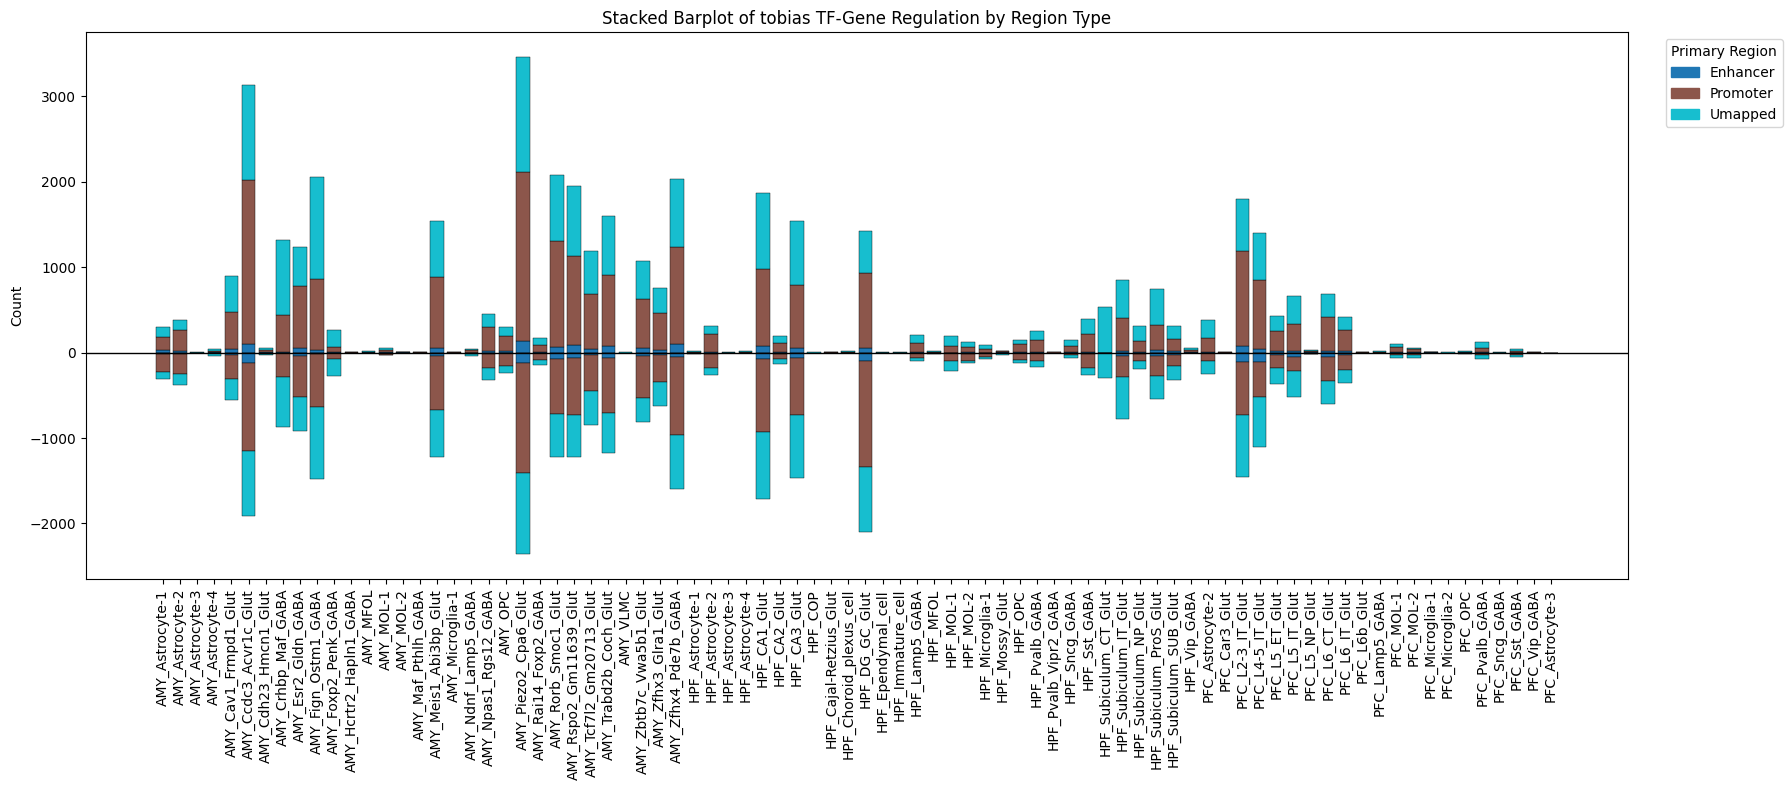

In [449]:
result_dict = {}
for exp, df_tmp_all in [("tobias", df_merged_region)]:#,("tobias", df_merged_region) #('DAR',df_DAR_expanded)

    df_tmp_promoter = df_tmp_all[df_tmp_all['primary_region']=='promoter']
    df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
    df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF','Direction'])
    #df_unq = df_tmp_promoter
    df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                     suffixes=('_promoter','_deg'),indicator='promoter')
    df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
    #df_deg_merge_gene = df_deg_merge
    df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['promoter']=='both']
    df_deg_merge_nomap = df_deg_merge_gene[df_deg_merge_gene['promoter']=='right_only']

    df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
    df_near_proximal = df_tmp_all[(df_tmp_all['primary_region']=='distal')]
    df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg_merge_nomap, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                        suffixes=('_prx','_degn'),indicator='nearproximal')
    


    df_deg_merge_proxima_unique = df_deg_merge_proxima.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
    df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
    df_deg_merge_promoter['TF_gene'] = 'Promoter'
    df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','Direction','TF_gene']]
    df_enhancer_final = df_deg_merge_proxima_unique[['Gene','Region Subclass','Direction','TF_gene']]
    df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
    show_stacked_barplot(df_grn_final, column_status="TF_gene", title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_filter_tf_gene_regiontype.pdf')

    df_deg_merge_promoter_size = df_deg_merge_promoter.groupby(['TF','Region Subclass']).size().reset_index()
    df_deg_pro_select = df_deg_merge_promoter_size[df_deg_merge_promoter_size[0]>10]
    df_deg_merge_promoter_5 = df_deg_merge_promoter.merge(df_deg_pro_select[['TF','Region Subclass']], how='inner', on=['TF','Region Subclass'])
    df_corr, df_pval = summerize_correlation(df_deg_merge_promoter_5, f'{exp}_log2FC', 'log2FC')
    df_corr = pd.DataFrame(list(df_corr.items()), columns=['TF', 'correlation'])
    df_pval = pd.DataFrame(list(df_pval.items()), columns=['TF', 'pvalue'])
    df_corr_pval = pd.merge(df_corr, df_pval, how='inner', on='TF')
    df_corr_pval.to_csv(f'/data2st1/junyi/output/atac1112/tobias/testdeg/correlation_{exp}_filter_tf_gene_promoter.csv', index=False)  


In [450]:
df_deg_merge_proxima.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Subclass,Region,Sex_deg,Method,Ensemble_deg,Gene_name,Neurotransmitter,Region subclass,promoter,nearproximal
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000084925,"""1810062O18Rik""",NN,PFC Astrocyte-2,right_only,right_only
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000087259,"""2610035D17Rik""",NN,PFC Astrocyte-2,right_only,right_only
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000097071,"""4930544I03Rik""",NN,PFC Astrocyte-2,right_only,right_only
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000115337,"""4930570B17Rik""",NN,PFC Astrocyte-2,right_only,right_only
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000039851,"""4932438H23Rik""",NN,PFC Astrocyte-2,right_only,right_only


In [58]:
# for exp, df_tmp_all in [("tobias", df_merged_region)]:#,("tobias", df_merged_region) #('DAR',df_DAR_expanded)

#     df_tmp_promoter = df_tmp_all[df_tmp_all['primary_region']=='promoter']
#     df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
#     df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF'])
#     df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene'], right_on=['Region Subclass','Gene'],
#                      suffixes=('_promoter','_deg'),indicator='promoter')
#     df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene'])
#     df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['promoter']=='both']
#     df_deg_merge_nomap = df_deg_merge_gene[df_deg_merge_gene['promoter']=='right_only']

#     df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
#     df_near_proximal = df_tmp_all[(df_tmp_all['primary_region']=='distal')]
#     df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg_merge_nomap, how='right', left_on=['Region Subclass','Gene'], right_on=['Region Subclass','Gene'],
#                         suffixes=('_prx','_degn'),indicator='nearproximal')

#     df_deg_merge_proxima_unique = df_deg_merge_proxima.drop_duplicates(subset=['Region Subclass','Gene'])
#     df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
#     df_deg_merge_promoter['TF_gene'] = 'Promoter'
#     df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','TF_gene']]
#     df_enhancer_final = df_deg_merge_proxima_unique[['Gene','Region Subclass','TF_gene']]
#     df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
#     #show_stacked_barplot(df_grn_final, column_status="TF_gene", title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_tf_gene_regiontype.pdf')


In [451]:
df_deg_merge_proxima.dropna()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Subclass,Region,Sex_deg,Method,Ensemble_deg,Gene_name,Neurotransmitter,Region subclass,promoter,nearproximal
88,chr8,107139936.0,107139945.0,metacluster_137.2cisbp__M01001_None,8.32578,-,chr8,107139731.0,107140232.0,2.00324,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000031924,"""Cyb5b""",NN,PFC Astrocyte-2,right_only,both
89,chr8,107139936.0,107139945.0,metacluster_137.2cisbp__M01001_None,8.32578,-,chr8,107139731.0,107140232.0,2.00324,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000031924,"""Cyb5b""",NN,PFC Astrocyte-2,right_only,both
191,chr1,92216290.0,92216299.0,metacluster_192.2cisbp__M01660_None,6.61831,-,chr1,92215938.0,92216439.0,0.60120,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000026313,"""Hdac4""",NN,PFC Astrocyte-2,right_only,both
212,chr8,125987510.0,125987520.0,metacluster_189.1cisbp__M00198_None,7.37810,+,chr8,125987137.0,125987638.0,0.87410,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000033998,"""Kcnk1""",NN,PFC Astrocyte-2,right_only,both
271,chr10,59285720.0,59285730.0,metacluster_13.3cisbp__M01731_None,8.39811,-,chr10,59285442.0,59285943.0,2.02198,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000019916,"""P4ha1""",NN,PFC Astrocyte-2,right_only,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44376,chr14,19987227.0,19987237.0,metacluster_183.3cisbp__M01490_None,7.52186,-,chr14,19987007.0,19987508.0,0.88622,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both
44377,chr14,19987227.0,19987237.0,metacluster_183.3cisbp__M01490_None,7.52186,-,chr14,19987007.0,19987508.0,0.88622,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both
44378,chr14,19987471.0,19987482.0,metacluster_5.1cisbp__M08039_None,9.00943,-,chr14,19987007.0,19987508.0,0.23880,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both
44379,chr14,19987471.0,19987482.0,metacluster_5.1cisbp__M08039_None,9.00943,-,chr14,19987007.0,19987508.0,0.23880,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both


In [452]:
df_group_deg = pd.read_csv('/data2st1/junyi/output/atac1112/tobias/CUSUS_male_L2level_mannualgroup_BPMF_1209version_deg.tsv', sep='\t')

In [453]:
df_group_deg = pd.read_csv('/data2st1/junyi/output/atac1112/tobias/CUSUS_male_L2level_mannualgroup_BPMF_1209version_deg.tsv', sep='\t')

In [454]:
df_group_deg_selected = df_group_deg[df_group_deg.Region.isin(['HPF','PFC','AMY']) & (df_group_deg.Sex == 'M')]

In [455]:
df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')

/tmp/ipykernel_3174066/2034175016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')


In [456]:
df_group_deg_explode = df_group_deg_selected.explode('Gene')

In [457]:
df_group_deg_explode=df_group_deg_explode

In [458]:
df_group_deg_explode

,Sex,Subclass,Region,Region subclass,Neurotransmitter,Direction,Region subclass_sex_direction,Group,intersection,dataset,Gene
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Adgrb3
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Adgrl3
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Csmd1
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Dach1
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Dmd
...,...,...,...,...,...,...,...,...,...,...,...
1009,M,PFC L4/5 IT Glut,PFC,PFC L4/5 IT Glut,Glut,Down,PFC_L4-5_IT_Glut_M_Down,other,"Pde10a,Pde1a,Pde4a,Cap2,Pde10a,Pde1a,Pde4a,Pde...",CUSUS_male,Pde4a
1010,M,PFC L5 IT Glut,PFC,PFC L5 IT Glut,Glut,Down,PFC_L5_IT_Glut_M_Down,G2-other,"Fstl4,Ntrk3",CUSUS_male,Fstl4
1010,M,PFC L5 IT Glut,PFC,PFC L5 IT Glut,Glut,Down,PFC_L5_IT_Glut_M_Down,G2-other,"Fstl4,Ntrk3",CUSUS_male,Ntrk3
1011,M,PFC Sst GABA,PFC,PFC Sst GABA,GABA,Down,PFC_Sst_GABA_M_Down,G12,"Fgf1,Vgf",CUSUS_male,Fgf1


In [459]:
def drop_sparse_by_count(df, min_count=2):
    row_mask = (df != 0).sum(axis=1) >= min_count
    col_mask = (df != 0).sum(axis=0) >= min_count
    return df.loc[row_mask, col_mask]

In [460]:
def gen_anno(df,groupby='group',column='Neurotransmitter_x'):
    df_nt = df.drop_duplicates().groupby([groupby,column]).size().reset_index()
    df_nt.columns = [groupby,column,'count']
    df_nt_pivot = df_nt.pivot(index=groupby, columns=column, values='count').fillna(0)
    return df_nt_pivot

In [461]:
df_all_cCRE= pd.concat([df_deg_merge_promoter[["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter','TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']], 
                        df_deg_merge_proxima[df_deg_merge_proxima.nearproximal=='both'][["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter',
                                                                                         'TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']]], axis=0)
df_all_cCRE=df_all_cCRE.drop_duplicates()
df_all_cCRE['Region'] = df_all_cCRE['Region Subclass'].str[:3].str.replace('HIP','HPF')


In [462]:
df_all_cCRE_BACK = df_all_cCRE.copy()

In [463]:
df_all_cCRE= df_all_cCRE_BACK#[df_all_cCRE.Region=='NN']


In [467]:
df_all_cCRE.head()

,Gene,Direction,Region Subclass,TF,Neurotransmitter,TFBS_chr,TFBS_start,TFBS_end,names,primary_region,log2FC,Region
2,4732471J01Rik,Up,PFC_Astrocyte-2,Tcf12,NN,chr7,25395949.0,25395958.0,chr7:25395463-25395964,promoter,0.053831,PFC
5,4833420G17Rik,Up,PFC_Astrocyte-2,Gabpa,NN,chr13,119462743.0,119462754.0,chr13:119462463-119462964,promoter,0.040075,PFC
8,4930402H24Rik,Up,PFC_Astrocyte-2,Hes7,NN,chr2,130840161.0,130840171.0,chr2:130839930-130840431,promoter,0.105143,PFC
11,4931406C07Rik,Up,PFC_Astrocyte-2,Gabpa,NN,chr9,15306274.0,15306285.0,chr9:15305942-15306443,promoter,0.078387,PFC
15,9430041J12Rik,Down,PFC_Astrocyte-2,Pou6f1,NN,chr7,4120560.0,4120570.0,chr7:4120532-4121033,promoter,-0.133827,PFC


In [472]:
df_group_deg_explode['Region Subclass'] = df_group_deg_explode['Region subclass'].str.replace(" ","_")

In [477]:
df_module_TFcross = pd.merge(df_all_cCRE,df_group_deg_explode,on=['Region Subclass','Direction','Gene'])

In [486]:
df_module_TFcross_back = df_module_TFcross.copy()

In [489]:
df_module_TFcross

,Gene,Direction,Region Subclass,TF,Neurotransmitter_x,TFBS_chr,TFBS_start,TFBS_end,names,primary_region,...,Region_x,Sex,Subclass,Region_y,Region subclass,Neurotransmitter_y,Region subclass_sex_direction,Group,intersection,dataset
0,Dclk1,Down,PFC_Astrocyte-2,Esr2,NN,chr3,55462037.0,55462046.0,chr3:55461566-55462067,promoter,...,PFC,M,Astrocyte-2,PFC,PFC Astrocyte-2,NN,PFC_Astrocyte-2_M_Down,G12,"Hdac4,Kank1,Mapk10,Pde10a,Pde4d,Pde7b,Plcb1,Tc...",CUSUS_male
1,Dclk1,Down,PFC_Astrocyte-2,Esr2,NN,chr3,55462037.0,55462046.0,chr3:55461566-55462067,promoter,...,PFC,M,Astrocyte-2,PFC,PFC Astrocyte-2,NN,PFC_Astrocyte-2_M_Down,G2-5,"Dclk1,Hdac4,Kank1",CUSUS_male
2,Dclk1,Down,PFC_Astrocyte-2,Esr2,NN,chr3,55462037.0,55462046.0,chr3:55461566-55462067,promoter,...,PFC,M,Astrocyte-2,PFC,PFC Astrocyte-2,NN,PFC_Astrocyte-2_M_Down,other,"Pde10a,Pde4d,Pde7b,Hdac4,Pde10a,Pde4d,Pde7b,Pl...",CUSUS_male
3,Dclk1,Down,PFC_Astrocyte-2,Esr2,NN,chr3,55462037.0,55462046.0,chr3:55461566-55462067,promoter,...,PFC,M,Astrocyte-2,PFC,PFC Astrocyte-2,NN,PFC_Astrocyte-2_M_Down,other,"Pde10a,Pde4d,Pde7b,Hdac4,Pde10a,Pde4d,Pde7b,Pl...",CUSUS_male
4,Kank1,Down,PFC_Astrocyte-2,Hic1,NN,chr19,25236963.0,25236972.0,chr19:25236679-25237180,promoter,...,PFC,M,Astrocyte-2,PFC,PFC Astrocyte-2,NN,PFC_Astrocyte-2_M_Down,G12,"Hdac4,Kank1,Mapk10,Pde10a,Pde4d,Pde7b,Plcb1,Tc...",CUSUS_male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41991,Sulf2,Up,AMY_OPC,Hic1,NN,chr2,166162333.0,166162342.0,chr2:166162013-166162514,distal,...,AMY,M,OPC,AMY,AMY OPC,NN,AMY_OPC_M_Up,G9,"Apoe,Atp1a2,Cd81,Cd9,Cspg5,Ednrb,Gpr17,Gpr37l1...",CUSUS_male
41992,Sulf2,Up,AMY_OPC,Hic1,NN,chr2,166162333.0,166162342.0,chr2:166162013-166162514,distal,...,AMY,M,OPC,AMY,AMY OPC,NN,AMY_OPC_M_Up,other,"Apoe,Atp1a2,Cd63,Cd81,Cd9,Cspg5,Ednrb,Gpr17,Gp...",CUSUS_male
41993,Sulf2,Up,AMY_OPC,Hic1,NN,chr2,166162333.0,166162342.0,chr2:166162013-166162514,distal,...,AMY,M,OPC,AMY,AMY OPC,NN,AMY_OPC_M_Up,other,"Apoe,Atp1a2,Cd63,Cd81,Cd9,Cspg5,Ednrb,Gpr17,Gp...",CUSUS_male
41994,Sulf2,Up,AMY_OPC,Hic1,NN,chr2,166162333.0,166162342.0,chr2:166162013-166162514,distal,...,AMY,M,OPC,AMY,AMY OPC,NN,AMY_OPC_M_Up,other,"Apoe,Atp1a2,Cd63,Cd81,Cd9,Cspg5,Ednrb,Gpr17,Gp...",CUSUS_male


In [505]:
df_module_TFcross = df_module_TFcross_back[df_module_TFcross_back.Region_x=='AMY']

In [509]:
df_module_TFcross = df_module_TFcross_back

In [515]:
df_merge

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
0,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,8.0,0.00501,-0.00866,-0.01367,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
1,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,10.0,0.00525,-0.00857,-0.01382,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
2,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,12.0,0.00574,-0.01065,-0.01639,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
3,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,14.0,0.00614,-0.01136,-0.01750,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
4,HIP_HPF_Sst_GABA_MC_corrected,metacluster_121.1cisbp__M00820_None,16.0,0.00618,-0.00944,-0.01562,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_121.1cisbp__M00820_None,...,Up,0.06037,M,Rorb,GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329987,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,40.0,0.00699,0.01418,0.00719,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329988,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,42.0,0.00722,0.01341,0.00618,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329989,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,44.0,0.00709,0.01336,0.00628,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2
329990,AMY_MOL-2_MW_corrected,metacluster_181.1cisbp__M08023_None,46.0,0.00698,0.01326,0.00629,AMY_MOL-2_MW,MW,AMY_MOL-2,metacluster_181.1cisbp__M08023_None,...,Down,-0.02979,M,Gli3,NN,1.051550e-67,MOL-2,AMY,Down,MOL-2


In [516]:
df_merge[df_merge['TF']=='Tcf4']

,celltype,motif,width,bgscore,midscore,tfbsscore,Region Subclass Condition,Condtion,Region Subclass,output_prefix,...,Direction,log2FC,Sex,Gene,Neurotransmitter,FDR,Subclass,Region,status,celltype.L2
1266,HIP_HPF_Sst_GABA_MC_corrected,metacluster_149.1cisbp__M01750_None,8.0,0.00715,-0.00341,-0.01056,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.00457,M,Tcf4,GABA,1.583270e-15,HPF_Sst_GABA,HPF,Down,HPF_Sst_GABA
1267,HIP_HPF_Sst_GABA_MC_corrected,metacluster_149.1cisbp__M01750_None,10.0,0.00719,-0.00168,-0.00886,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.00457,M,Tcf4,GABA,1.583270e-15,HPF_Sst_GABA,HPF,Down,HPF_Sst_GABA
1268,HIP_HPF_Sst_GABA_MC_corrected,metacluster_149.1cisbp__M01750_None,12.0,0.00743,-0.00239,-0.00982,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.00457,M,Tcf4,GABA,1.583270e-15,HPF_Sst_GABA,HPF,Down,HPF_Sst_GABA
1269,HIP_HPF_Sst_GABA_MC_corrected,metacluster_149.1cisbp__M01750_None,14.0,0.00771,-0.00310,-0.01081,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.00457,M,Tcf4,GABA,1.583270e-15,HPF_Sst_GABA,HPF,Down,HPF_Sst_GABA
1270,HIP_HPF_Sst_GABA_MC_corrected,metacluster_149.1cisbp__M01750_None,16.0,0.00842,-0.00641,-0.01484,HIP_HPF_Sst_GABA_MC,MC,HPF_HPF_Sst_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.00457,M,Tcf4,GABA,1.583270e-15,HPF_Sst_GABA,HPF,Down,HPF_Sst_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280573,AMY_AMY_Esr2_Gldn_GABA_MW_corrected,metacluster_149.1cisbp__M01750_None,40.0,0.01070,0.00064,-0.01007,AMY_AMY_Esr2_Gldn_GABA_MW,MW,AMY_AMY_Esr2_Gldn_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.15781,M,Tcf4,GABA,8.079950e-155,AMY_Esr2_Gldn_GABA,AMY,Down,AMY_Esr2_Gldn_GABA
280574,AMY_AMY_Esr2_Gldn_GABA_MW_corrected,metacluster_149.1cisbp__M01750_None,42.0,0.01073,0.00107,-0.00966,AMY_AMY_Esr2_Gldn_GABA_MW,MW,AMY_AMY_Esr2_Gldn_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.15781,M,Tcf4,GABA,8.079950e-155,AMY_Esr2_Gldn_GABA,AMY,Down,AMY_Esr2_Gldn_GABA
280575,AMY_AMY_Esr2_Gldn_GABA_MW_corrected,metacluster_149.1cisbp__M01750_None,44.0,0.01066,0.00162,-0.00904,AMY_AMY_Esr2_Gldn_GABA_MW,MW,AMY_AMY_Esr2_Gldn_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.15781,M,Tcf4,GABA,8.079950e-155,AMY_Esr2_Gldn_GABA,AMY,Down,AMY_Esr2_Gldn_GABA
280576,AMY_AMY_Esr2_Gldn_GABA_MW_corrected,metacluster_149.1cisbp__M01750_None,46.0,0.01066,0.00201,-0.00865,AMY_AMY_Esr2_Gldn_GABA_MW,MW,AMY_AMY_Esr2_Gldn_GABA,metacluster_149.1cisbp__M01750_None,...,Down,-0.15781,M,Tcf4,GABA,8.079950e-155,AMY_Esr2_Gldn_GABA,AMY,Down,AMY_Esr2_Gldn_GABA


Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 21.344444444444445 mm


<Figure size 1000x200 with 0 Axes>

<Figure size 2000x200 with 0 Axes>

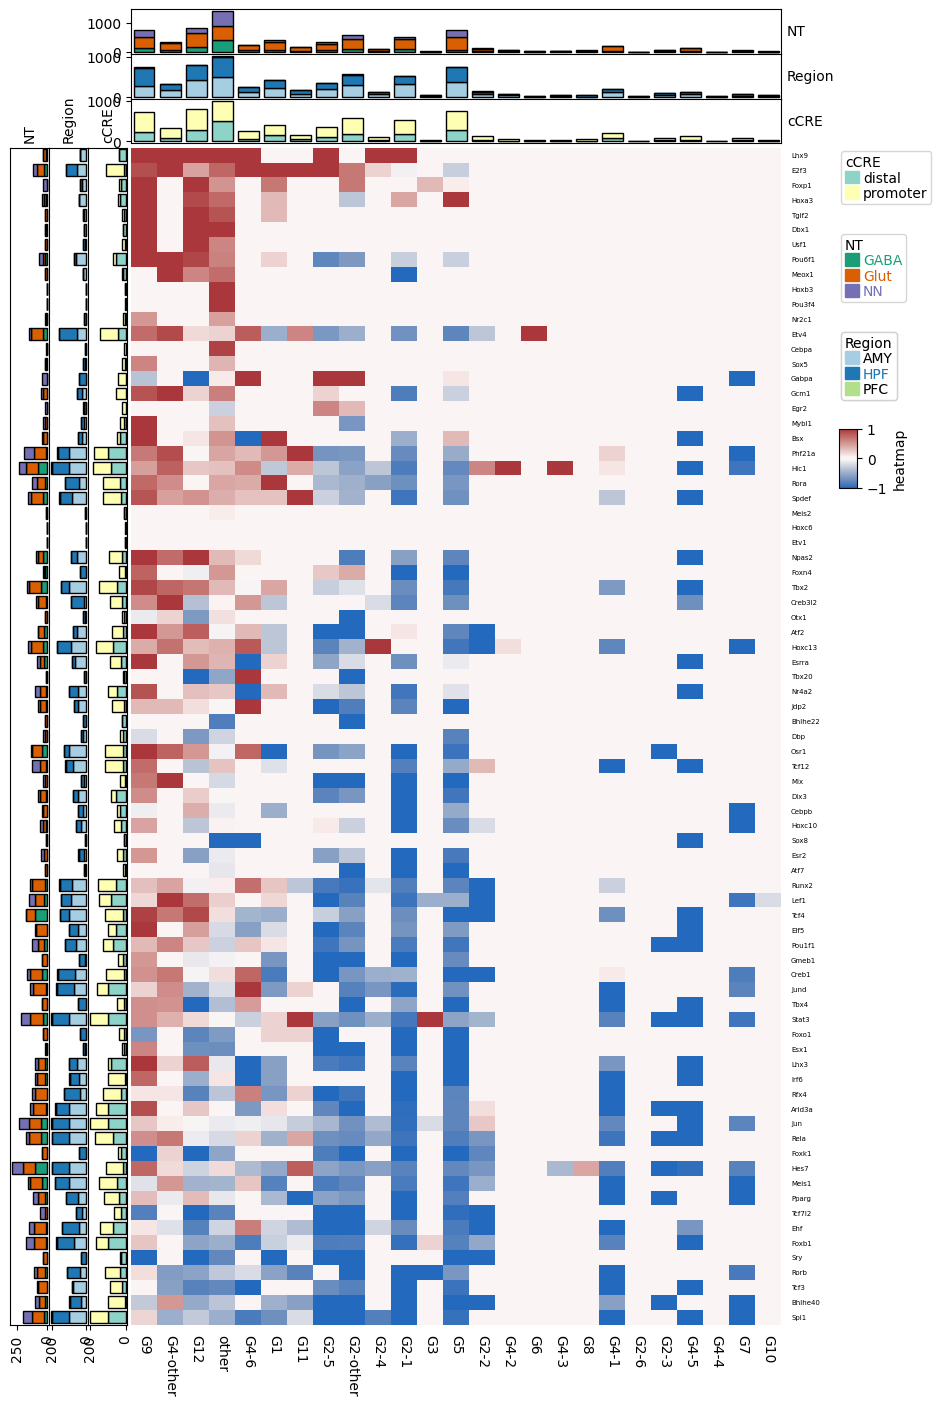

In [512]:
df_count = (
    df_module_TFcross
    .groupby(["Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_module_TFcross
    .groupby(["Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 5
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

Group=matrix.index.tolist()
# sort Group by group name
df_order= pd.DataFrame({'Group':Group})
df_order['number'] = df_order['Group'].str.split('-').str[0]
df_order['number'] = df_order['number'].str.replace('G','')
df_order['number'] = df_order['number'].str.replace('other','1000')
df_order['number'] = df_order['number'].astype(int)
df_order.sort_values(by=['number','Group'], inplace=True)
direction_score_matrix=direction_score_matrix.loc[df_order['Group'], :]
df_hant = gen_anno(df_module_TFcross,groupby='Group',column='Neurotransmitter_x')
df_region = gen_anno(df_module_TFcross,groupby='Group',column='Region_x')
df_pm = gen_anno(df_module_TFcross,groupby='Group',column='primary_region')


df_ha_t = gen_anno(df_module_TFcross,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_module_TFcross,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_module_TFcross,groupby='TF',column='primary_region')
order = direction_score_matrix[direction_score_matrix>0].sum(axis=1).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[order, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]
from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
col_ha = HeatmapAnnotation(
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,500)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,500),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,500),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

)
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,100)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,100),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,100),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(10, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=False,center=0,left_annotation=row_ha,
        cmap='vlag',
                yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 10},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.show()


In [ ]:

import seaborn as sns
plt.figure(figsize=(10, 10))
g=sns.clustermap(drop_sparse_by_count(direction_score_matrix).T, cmap="vlag", annot=False, fmt="d",
                   xticklabels=True,figsize=(10,20),center=0,col_cluster=False,row_cluster=False,
                yticklabels=True
)
g.ax_heatmap.tick_params(axis="x", labelsize=8, rotation=90)
g.ax_heatmap.tick_params(axis="y", labelsize=8)

plt.show()

In [ ]:
# plot_df = (
#     direction_score_matrix
#     .stack()
#     .reset_index()
#     .rename(columns={0: "DirectionScore"})
# )

# plot_df["GeneCount"] = (
#     matrix.clip(0,100)
#     .stack()
#     .values
# )
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 20))

# ax = sns.scatterplot(
#     data=plot_df,
#     x="Group",
#     y="TF",
#     size="GeneCount",
#     hue="DirectionScore",
#     palette="vlag",
#     sizes=(10, 300),          # 圆大小范围，可调
#     hue_norm=(-1, 1),         # DirectionScore 范围
#     edgecolor="black",
#     linewidth=0.3
# )

# plt.xticks(rotation=90)
# plt.xlabel("")
# plt.ylabel("")

# # colorbar（比 legend 更专业）
# norm = plt.Normalize(-1, 1)
# sm = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
# sm.set_array([])
# #cbar = plt.colorbar(sm)
# #cbar.set_label("DirectionScore")

# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Gene count")
# plt.tight_layout()
# plt.show()


In [ ]:
for region in df_deg.Region.unique():
    for exp, df_tmp_all in [("DAR", df_DAR), ("tobias", df_merged_region)]:
        df_deg_region = df_deg[df_deg['Region'] == region]
        df_tmp = df_tmp_all[df_tmp_all['Region'] == region]
        df_tmp_promoter = df_tmp[df_tmp['primary_region']=='promoter']
        draw_venndiagram(df_tmp_promoter, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_promoter_deg.pdf')

        df_proximal = df_tmp[(df_tmp['primary_region']=='distal')&(df_tmp['distance'].abs() <= 50000)]
        draw_venndiagram(df_proximal, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_proximal_deg.pdf')
        
        df_distal = df_tmp[(df_tmp['primary_region']=='distal')&(df_tmp['distance'].abs() > 50000)]
        draw_venndiagram(df_distal, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_distal_deg.pdf')

In [ ]:
df_DAR_expanded

In [ ]:
df_DAR_expanded_TF = df_DAR_expanded.groupby(['TFs','Region Subclass']).mean().reset_index()

In [ ]:
df_DAR_expanded_TF = df_DAR_expanded.groupby(['gene_name','TFs','Region Subclass']).mean().reset_index()

In [ ]:
df_DAR_expanded_TF

In [ ]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    results['log2FC'] = results['MC_MW_change']
    results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results

In [ ]:
df_DAR_expanded_TF['TF'] = df_DAR_expanded_TF['TFs']

In [ ]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']

    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if 'FDR' not in results.columns:
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results
df_DAR_expanded_TF = add_columns(df_DAR_expanded_TF)

In [ ]:
df_TF_jun

In [ ]:
df_scp = pd.read_csv('/data2st1/junyi/output/atac1112/scenic/scplus_region_based_AUC_filterd.csv',index_col=0)

In [ ]:
df_deg

In [ ]:
df_scp

In [ ]:
IoUs= []
TFs = []
for TF in df_DAR_expanded_TF.TF.unique():
    df_TF_jun = df_DAR_expanded_TF[df_DAR_expanded_TF.TF==TF]
    #df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_DAR_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)

In [ ]:
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [ ]:
df_merged_region['distance_weight'] = df_merged_region['distance'].apply(archr_distance_weight)

In [ ]:
df_merged_region["MC_Weighted"] = df_merged_region["MC_score"] * df_merged_region["distance_weight"]
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [ ]:
df_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_{data_test}.csv')

In [ ]:
for celltype in df_merged_region['Region Subclass'].unique():
    df_tmp = df_merged_region[df_merged_region['Region Subclass']==celltype]
    df_tmp.to_csv(os.path.join(outdir, f'tobias_regions_{celltype}.csv'), index=False)

In [ ]:
for module in df_module['Module'].unique():
    df_sub = df_module[df_module['Module'] == module]
    focus = df_sub['TF'].values
    df_merged_region_focus = df_merged_region[df_merged_region['TF'].isin(focus)]
    df_merged_region_focus_grouped = copute_weighted_score(df_merged_region_focus)
    df_merged_region_focus_grouped.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.95)
low_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_merged_region_focus_grouped['MC_MW_log2fc'].hist(bins=200, alpha=0.7, color='skyblue', edgecolor='black')
# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-10, 10)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_merged_region_focus_grouped['MC_MW_log2fc'].mean()
std_val = df_merged_region_focus_grouped['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_merged_region_focus_grouped)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_merged_region_focus_grouped['absLog2FC'] = df_merged_region_focus_grouped['log2FC'].abs()
df_merged_region_focus_grouped[df_merged_region_focus_grouped.absLog2FC > 0.1]

In [ ]:
df_merged_region_focus_grouped['Sex'] = 'M'

In [ ]:
df_merged_region.to_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all_fc1.csv')

In [ ]:
df_DAR

In [ ]:
df_merged_DAR = pd.merge(df_regions_f, df_DAR, how='inner', left_on=['names','Region Subclass'], right_on=['names','Region Subclass'])

In [ ]:
df_merged_DAR['TF'] = df_merged_DAR['TFBS_name'].map(dict_tfbs2tf)

In [ ]:
df_merged_DAR.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_regions['MC_MW_log2fc'].quantile(0.95)
low_95 = df_regions['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_regions['MC_MW_log2fc'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-4, 4)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_regions['MC_MW_log2fc'].mean()
std_val = df_regions['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_regions)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [ ]:
df_regions_focus = df_regions.loc[df_regions['TF'].isin(focus)]

In [ ]:
df_regions_focus = df_regions_focus[df_regions_focus.absLog2FC>0.1]

In [ ]:
df_regions_focus

In [ ]:
df_modules_gene = glob.glob('/data2st1/junyi/output/atac1112/tobias/tobias_*_gene_summary_cisbp.csv')

In [ ]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [ ]:
df_deg

In [ ]:
IoU =[]
pct =[] 
for module in df_module['Module'].unique():
    df_TF_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv')
    df_moduledeg= pd.merge(df_TF_module, df_deg.loc[:,['Region Subclass','Direction','FDR']], 
                               left_on=['Region Subclass','gene_name','Direction'],
                               right_on=['Region Subclass','Gene','Direction'])
    df_moduledeg.to_csv(f'/data2st1/junyi/output/atac1112/tobias/degfiltererd/tobias_{module}_deg_summary_cisbp.csv', index=False)
    for region in df_deg['Region'].unique():
        df_TF_module_region = df_TF_module[df_TF_module['Region Subclass'].str.contains(region)]
        df_deg_region = df_deg[df_deg['Region']==region]
        set1,set2=draw_venndiagram(df_TF_module_region,df_deg_region)
        print(module, region)


In [ ]:
df_moduledeg

In [ ]:
df_regions_annotated = pd.merge(df_regions,df_annotattion_columns,on='names')
outdir="/data2st1/junyi/output/atac1112/tobias/region_celltype.l2"
outdir

df_deg

In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['names']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    #gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    gene_list2 = df2['names']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "DAR"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

draw_venndiagram(df_regions_annotated[df_regions_annotated.absLog2FC>0.1],df_DAR)


In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("DAR", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2
draw_venndiagram(df_DAR,df_deg)

In [ ]:
df_gene_tobias = pd.merge(df_regions_annotated,df_deg,left_on=['Region Subclass','gene_name'],right_on=['Region Subclass','Gene'])

In [ ]:
df_gene_tobias[df_gene_tobias.Direction_y==df_gene_tobias.Direction_x]

In [ ]:
df_gene_consist = pd.merge(df_regions_focus,df_deg,left_on=['Region Subclass','gene_name','Direction'],right_on=['Region Subclass','Gene','Direction'])

In [ ]:
len(df_gene_tobias)

In [ ]:
df_regions

In [ ]:
df_regions_focus = pd.merge(df_regions_focus,df_annotattion_columns,left_on='names',right_on='names')

In [ ]:
df_regions_focus

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNP_dar_annotated.csvdir/tobias_focus.csv')

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated_focusTFs.csv', index=False)

In [ ]:
focus

In [ ]:
order = cm.dendrogram_row.dendrogram["leaves"]
tf_clusters = {cm.data2d.index[order[i]]: labels[i] for i in range(n)}

tf_clusters


In [ ]:
df_DAR_expanded_TF

In [ ]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

In [ ]:
df_annot_TF= pd.read_csv('/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_cisbp.csv')
df_annot_TF['Module'] = df_annot_TF['Module'].astype('string')
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_3R['Category'] = df_3R['TF'].map(tf_map)
df_3R['Category'].fillna('Other', inplace=True)
df_3R['Category']= df_3R['Category'].astype('string')

In [ ]:
results['Category'] = results['TF'].map(tf_map)
results['Category'].fillna('Other', inplace=True)
results['Category']= results['Category'].astype('string')

In [ ]:
cm2 = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(10,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_ANNO_{data_test}.pdf')


In [ ]:
df_scenic = pd.read_csv(f'/data2st1/junyi/output/atac1112/scenic/scplus_region_based_AUC_filterd.csv', index_col=0)
df_scenic['Region Subclass'] = df_scenic['sample']
df_scenic['Direction'] = df_scenic['nlog10_p_val_adj'].apply(lambda x: 'Up' if x > 0 else 'Down')
df_scenic['ctname'] = df_scenic['Region Subclass']
df_scenic = add_columns(df_scenic)
# df_scenic['Category'] = df_scenic['TF'].map(tf_map)
# df_scenic['Category'].fillna('Other', inplace=True)
# df_scenic['Category']= df_scenic['Category'].astype('string')
cmsc = draw_tf_heatmap(df_scenic, value_col="nlog10_p_val_adj", clipping=10,figure_size=(10,10), save_fig=f'/home/junyichen/code/scmmd/figures/heatmapscenic_{data_test}.pdf')

In [ ]:
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
# 修改了 my_module.py 后，重新加载
importlib.reload(utils)


In [ ]:
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_DAR_expanded_TF['Category'] = df_DAR_expanded_TF['TF'].map(tf_map)
df_DAR_expanded_TF['Category'].fillna('Other', inplace=True)
df_DAR_expanded_TF['Category']= df_DAR_expanded_TF['Category'].astype('string')
cmnDAR = draw_tf_heatmap(df_DAR_expanded_TF[(df_DAR_expanded_TF.Neurotransmitter!="NN") & (df_DAR_expanded_TF.Category!="Other")],value_col="log2FC",clipping=0.1,figure_size=(15,15))


In [ ]:
cmgene = draw_tf_heatmap(df_3R[(df_3R.Neurotransmitter!='NN') & (df_3R.Category!="Other")],value_col="log2FC",clipping=10)

In [ ]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 10))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=20)

In [ ]:
df_3R

In [ ]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
